# DCIR Simulation with PyBaMM

This notebook demonstrates how to perform Direct Current Internal Resistance (DCIR) simulation using PyBaMM with BYD Blade Prismatic 135Ah cell parameters.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 135Ah
- **Simulations**: DCIR (7 time points)

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [1]:
# Import required libraries
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Force reload of module to get latest changes
import sys
if 'model_library.spmet_dcir' in sys.modules:
    del sys.modules['model_library.spmet_dcir']
    
from model_library.spmet_dcir import simulate_dcir


## 2. Setup PyBaMM Model Parameters

Configure PyBaMM SPMe (Single Particle Model with electrolyte effects) using the cell design parameters.

In [2]:
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
upper_voltage_cutoff = cell_design_manifest["cell_design"]["upper_voltage_cutoff"]["value"]
lower_voltage_cutoff = cell_design_manifest["cell_design"]["lower_voltage_cutoff"]["value"]
dcir_config = {
    'ambient_temperature': 298.15,
    'initial_temperature': 298.15,
    'contact_resistance': 1e-5,
    'total_heat_transfer_coefficient': 0.01,
    'cooling_surface_area': 0.1,
    'initial_soc': 0.5,
    'upper_voltage_cutoff': upper_voltage_cutoff,
    'lower_voltage_cutoff': lower_voltage_cutoff,
    'period': '0.01 second',
    'experiments': [f'Discharge at 1C for 30 seconds or until {lower_voltage_cutoff} V'],
    'experiment_labels': [f'1C_DCIR'],
}

## 3. Run DCIR Simulation

In [3]:


# Load cell manifest
manifest_path = "../cells/Tesla_Model3_Prismatic_160Ah_manifest.json"
with open(manifest_path, 'r') as f:
    manifest = json.load(f)
cell_design = manifest['cell_design']
kpis = manifest['kpis']

# Run DCIR simulation at default conditions (50% SOC, 25°C, 1C)
dcir_result = simulate_dcir(cell_design, kpis)

if dcir_result['success']:
    print('DCIR values at key time points (mOhm):')
    for t, v in dcir_result['dcir_mOhm'].items():
        print(f'  t={t:.1f}s: {v:.3f} mOhm')
else:
    print('Simulation failed:', dcir_result.get('error'))


Building model parameters from cell design...

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  60.01 Ah, Error = 62.751%
Iteration  1: Capacity =  60.01 Ah, Error = 62.751%
Iteration  2: Capacity = 163.23 Ah, Error =  1.324%
Iteration  2: Capacity = 163.23 Ah, Error =  1.324%
Iteration  3: Capacity = 161.09 Ah, Error =  0.008%
--------------------------------------------------------------------------------
Converged after 3 iterations!

DCIR PULSE SIMULATION
Conditions: SOC=50%, T=25.0°C, C-rate=1.0
Iteration  3: Capacity = 161.09 Ah, Error =  0.008%
--------------------------------------------------------------------------------
Converged after 3 iterations!

DCIR PULSE SIMULATION
Conditions: SOC=50%, T=25.0°C, C-rate=1.0

DCIR Results:
----------------------------------------
  t=  0.1s: DCIR = 0.011 mOhm
  t=  1.0s: DCIR = 0.018 mOhm
  t= 10.0s: D


Plotting DCIR results with overpotential breakdown...


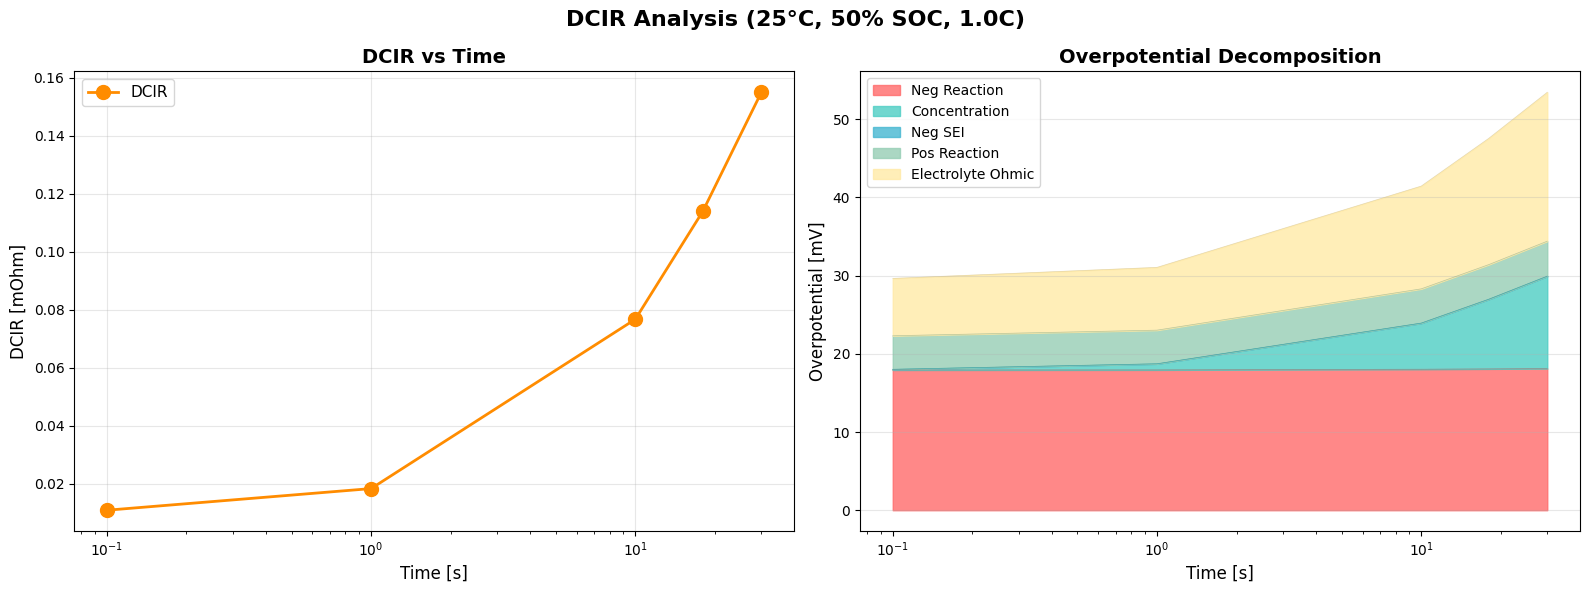


Overpotential Summary at t=10s:
  neg_reaction_V: 18.033 mV
  concentration_V: -5.898 mV
  neg_sei_V: 0.000 mV
  pos_reaction_V: -4.381 mV
  elyte_ohmic_V: -13.145 mV


In [4]:
if dcir_result['success']:
    # Extract data from result
    print("\nPlotting DCIR results with overpotential breakdown...")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Extract time points and DCIR values
    time_points = sorted(dcir_result['dcir_mOhm'].keys())
    dcir_values = [dcir_result['dcir_mOhm'][t] for t in time_points]
    
    # Plot 1: DCIR vs Time
    ax1.plot(time_points, dcir_values, 'o-', linewidth=2, markersize=10, color='darkorange', label='DCIR')
    ax1.set_xlabel('Time [s]', fontsize=12)
    ax1.set_ylabel('DCIR [mOhm]', fontsize=12)
    ax1.set_title('DCIR vs Time', fontsize=14, fontweight='bold')
    ax1.set_xscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    
    # Plot 2: Overpotential Breakdown (filled stacked area plot)
    overpots = dcir_result['overpotentials']
    
    # Extract overpotential components (convert to mV for better visualization)
    neg_reaction = np.array([abs(overpots[t]['neg_reaction_V']) * 1000 for t in time_points])
    concentration = np.array([abs(overpots[t]['concentration_V']) * 1000 for t in time_points])
    neg_sei = np.array([abs(overpots[t]['neg_sei_V']) * 1000 for t in time_points])
    pos_reaction = np.array([abs(overpots[t]['pos_reaction_V']) * 1000 for t in time_points])
    elyte_ohmic = np.array([abs(overpots[t]['elyte_ohmic_V']) * 1000 for t in time_points])
    
    # Create stacked data
    y1 = neg_reaction
    y2 = y1 + concentration
    y3 = y2 + neg_sei
    y4 = y3 + pos_reaction
    y5 = y4 + elyte_ohmic
    
    # Create filled stacked area plot
    ax2.fill_between(time_points, 0, y1, label='Neg Reaction', color='#FF6B6B', alpha=0.8)
    ax2.fill_between(time_points, y1, y2, label='Concentration', color='#4ECDC4', alpha=0.8)
    ax2.fill_between(time_points, y2, y3, label='Neg SEI', color='#45B7D1', alpha=0.8)
    ax2.fill_between(time_points, y3, y4, label='Pos Reaction', color='#96CEB4', alpha=0.8)
    ax2.fill_between(time_points, y4, y5, label='Electrolyte Ohmic', color='#FFEAA7', alpha=0.8)
    
    # Add lines at boundaries for clarity
    ax2.plot(time_points, y1, '-', color='#CC5555', linewidth=0.5, alpha=0.5)
    ax2.plot(time_points, y2, '-', color='#3EACA0', linewidth=0.5, alpha=0.5)
    ax2.plot(time_points, y3, '-', color='#3595AD', linewidth=0.5, alpha=0.5)
    ax2.plot(time_points, y4, '-', color='#7CA590', linewidth=0.5, alpha=0.5)
    ax2.plot(time_points, y5, '-', color='#CCBB83', linewidth=0.5, alpha=0.5)
    
    ax2.set_xlabel('Time [s]', fontsize=12)
    ax2.set_ylabel('Overpotential [mV]', fontsize=12)
    ax2.set_title('Overpotential Decomposition', fontsize=14, fontweight='bold')
    ax2.set_xscale('log')
    ax2.legend(fontsize=10, loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add overall title
    conditions = dcir_result['conditions']
    title_str = f"DCIR Analysis ({conditions['temperature_C']:.0f}°C, {conditions['initial_soc']*100:.0f}% SOC, {conditions['c_rate']}C)"
    fig.suptitle(title_str, fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print overpotential summary
    print("\nOverpotential Summary at t=10s:")
    for key, val in overpots[10.0].items():
        print(f"  {key}: {val*1000:.3f} mV")
else:
    print("No successful simulation to plot.")


## 4. Uncertainty Quantification with Polynomial Chaos Expansion

Perform uncertainty analysis using PCE to understand how parameter variations affect DCIR.

### 4.1 Define Parameter Distributions

Define uncertainty ranges for key parameters (±10% variation).

In [5]:
import chaospy as cp

# Define parameter distributions (±10% uniform variation)
soc_dist = cp.Uniform(0.45, 0.55)  # SOC variation around 50%
temp_dist = cp.Uniform(293.15, 303.15)  # Temperature variation ±5°C around 25°C (298.15K)
crate_dist = cp.Uniform(0.9, 1.1)  # C-rate variation ±10%

# Create joint distribution
joint_dist = cp.J(soc_dist, temp_dist, crate_dist)

print(f"Parameter distributions defined:")
print(f"  SOC: {soc_dist}")
print(f"  Temperature: {temp_dist}")
print(f"  C-rate: {crate_dist}")


Parameter distributions defined:
  SOC: Uniform(lower=0.45, upper=0.55)
  Temperature: Uniform(lower=293.15, upper=303.15)
  C-rate: Uniform(lower=0.9, upper=1.1)


### 4.2 Generate PCE Sampling Points

Use Gaussian quadrature for optimal sampling.

In [6]:
# Generate polynomial chaos expansion with order 3
pce_order = 3
polynomial_expansion = cp.generate_expansion(pce_order, joint_dist)

# Generate quadrature nodes and weights for PCE
nodes, weights = cp.generate_quadrature(pce_order, joint_dist, rule="gaussian")
samples = nodes  # shape: (n_params, n_samples)

print(f"\nPCE Configuration:")
print(f"  Polynomial order: {pce_order}")
print(f"  Number of basis functions: {len(polynomial_expansion)}")
print(f"  Number of sample points: {samples.shape[1]}")
print(f"\nSample points shape: {samples.shape}")
print(f"  Dimension 0 (SOC): {samples.shape[0]} parameters")
print(f"  Dimension 1 (samples): {samples.shape[1]} evaluations")



PCE Configuration:
  Polynomial order: 3
  Number of basis functions: 20
  Number of sample points: 64

Sample points shape: (3, 64)
  Dimension 0 (SOC): 3 parameters
  Dimension 1 (samples): 64 evaluations

  Polynomial order: 3
  Number of basis functions: 20
  Number of sample points: 64

Sample points shape: (3, 64)
  Dimension 0 (SOC): 3 parameters
  Dimension 1 (samples): 64 evaluations


### 4.3 Run DCIR Simulations at PCE Sample Points

Evaluate the model at each sample point.

In [7]:
# Run simulations at all sample points
print(f"\nRunning {samples.shape[1]} DCIR simulations for PCE...")

# Extract parameter arrays
soc_samples = samples[0, :]
temp_samples = samples[1, :]
crate_samples = samples[2, :]

# Run sweep simulation
pce_result = simulate_dcir(
    cell_design, 
    kpis, 
    initial_soc=soc_samples,
    temperature_K=temp_samples,
    c_rate=crate_samples
)

if pce_result['success']:
    print(f"✓ Successfully completed {pce_result['num_simulations']} simulations")
    print(f"\nSample conditions:")
    print(f"  SOC range: [{soc_samples.min():.3f}, {soc_samples.max():.3f}]")
    print(f"  Temperature range: [{temp_samples.min():.2f}K, {temp_samples.max():.2f}K]")
    print(f"  C-rate range: [{crate_samples.min():.3f}, {crate_samples.max():.3f}]")
else:
    print(f"✗ PCE simulations failed: {pce_result.get('error')}")



Running 64 DCIR simulations for PCE...

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  60.01 Ah, Error = 62.751%
Iteration  1: Capacity =  60.01 Ah, Error = 62.751%
Iteration  2: Capacity = 163.23 Ah, Error =  1.324%
Iteration  2: Capacity = 163.23 Ah, Error =  1.324%
Iteration  3: Capacity = 161.09 Ah, Error =  0.008%
--------------------------------------------------------------------------------
Converged after 3 iterations!

RUNNING DCIR SWEEP

--- Temperature: 21°C ---
Iteration  3: Capacity = 161.09 Ah, Error =  0.008%
--------------------------------------------------------------------------------
Converged after 3 iterations!

RUNNING DCIR SWEEP

--- Temperature: 21°C ---
  SOC=46%, C=0.9138863688405946C: DCIR@10s = 0.091 mΩ
  SOC=46%, C=0.9138863688405946C: DCIR@10s = 0.091 mΩ
  SOC=46%, C=0.9660018956415145C: DCIR@10s = 0.091 mΩ
  SOC=46%,

KeyboardInterrupt: 

### 4.4 Build PCE Surrogate Model

Construct polynomial surrogate models for DCIR at each time point.

In [ ]:
if pce_result['success']:
    # Extract DCIR values at each time point for all samples
    time_points = [0.1, 1.0, 10.0, 18.0, 30.0]
    dcir_evaluations = {}
    
    for t in time_points:
        dcir_values = []
        for sim in pce_result['surface_data']:
            if sim['success']:
                dcir_values.append(sim['dcir_mOhm'][t])
            else:
                dcir_values.append(np.nan)
        dcir_evaluations[t] = np.array(dcir_values)
    
    # Build PCE surrogate models for each time point
    pce_models = {}
    for t in time_points:
        pce_models[t] = cp.fit_regression(
            polynomial_expansion, 
            samples, 
            dcir_evaluations[t]
        )
    
    print("✓ PCE surrogate models built for all time points")
    print(f"  Time points: {time_points}")


### 4.5 Statistical Analysis and Sensitivity Indices

Calculate statistics and Sobol sensitivity indices.

In [ ]:
if pce_result['success']:
    # Calculate statistics for each time point
    pce_stats = {}
    
    for t in time_points:
        model = pce_models[t]
        
        # Mean and standard deviation
        mean = cp.E(model, joint_dist)
        std = cp.Std(model, joint_dist)
        
        # Sobol sensitivity indices (first order)
        sobol = cp.Sens_m(model, joint_dist)
        
        pce_stats[t] = {
            'mean': float(mean),
            'std': float(std),
            'sobol_soc': float(sobol[0]),
            'sobol_temp': float(sobol[1]),
            'sobol_crate': float(sobol[2])
        }
    
    # Print summary
    print("\n" + "="*80)
    print("PCE STATISTICAL ANALYSIS")
    print("="*80)
    
    for t in time_points:
        stats = pce_stats[t]
        print(f"\nTime = {t:.1f}s:")
        print(f"  Mean DCIR: {stats['mean']:.4f} ± {stats['std']:.4f} mOhm")
        print(f"  Sobol Indices (first order):")
        print(f"    SOC:         {stats['sobol_soc']:.4f} ({stats['sobol_soc']*100:.2f}%)")
        print(f"    Temperature: {stats['sobol_temp']:.4f} ({stats['sobol_temp']*100:.2f}%)")
        print(f"    C-rate:      {stats['sobol_crate']:.4f} ({stats['sobol_crate']*100:.2f}%)")
    
    print("\n" + "="*80)


### 4.6 Visualize PCE Results

Plot mean, uncertainty bounds, and sensitivity indices.

In [ ]:
if pce_result['success']:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Extract statistics
    means = [pce_stats[t]['mean'] for t in time_points]
    stds = [pce_stats[t]['std'] for t in time_points]
    lower_bound = [m - 2*s for m, s in zip(means, stds)]
    upper_bound = [m + 2*s for m, s in zip(means, stds)]
    
    # Plot 1: DCIR with uncertainty bounds
    ax1.plot(time_points, means, 'o-', linewidth=2, markersize=8, 
             color='darkorange', label='PCE Mean', zorder=3)
    ax1.fill_between(time_points, lower_bound, upper_bound, 
                     alpha=0.3, color='orange', label='95% CI (±2σ)')
    
    # Add sample points
    for sim in pce_result['surface_data'][:10]:  # Plot first 10 samples for clarity
        if sim['success']:
            sample_dcir = [sim['dcir_mOhm'][t] for t in time_points]
            ax1.plot(time_points, sample_dcir, 'o-', linewidth=0.5, 
                    markersize=3, alpha=0.3, color='gray')
    
    ax1.set_xlabel('Time [s]', fontsize=12)
    ax1.set_ylabel('DCIR [mOhm]', fontsize=12)
    ax1.set_title('DCIR with Uncertainty (PCE)', fontsize=14, fontweight='bold')
    ax1.set_xscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    
    # Plot 2: Sobol sensitivity indices
    sobol_soc = [pce_stats[t]['sobol_soc'] for t in time_points]
    sobol_temp = [pce_stats[t]['sobol_temp'] for t in time_points]
    sobol_crate = [pce_stats[t]['sobol_crate'] for t in time_points]
    
    x_pos = np.arange(len(time_points))
    width = 0.25
    
    ax2.bar(x_pos - width, sobol_soc, width, label='SOC', color='#FF6B6B')
    ax2.bar(x_pos, sobol_temp, width, label='Temperature', color='#4ECDC4')
    ax2.bar(x_pos + width, sobol_crate, width, label='C-rate', color='#FFEAA7')
    
    ax2.set_xlabel('Time Point [s]', fontsize=12)
    ax2.set_ylabel('Sobol Index (First Order)', fontsize=12)
    ax2.set_title('Sensitivity Analysis', fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'{t:.1f}' for t in time_points])
    ax2.set_ylim([0, 1])
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    fig.suptitle('Polynomial Chaos Expansion Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nPlots generated: DCIR uncertainty bounds and Sobol sensitivity indices")
